# Assignment — Week 06 · Day 30 (AM+PM)
**PG Diploma · AI-ML & Agentic AI Engineering · IIT Gandhinagar**  
**Topic:** Logistic Regression — End-to-End ML Pipeline  
**Dataset:** SUV Purchase Dataset

---

## Part B — Stretch Problem

> **Note:** Run Part A first (or re-run the setup cell below) so all variables are ready.

In [1]:
# ── Setup: re-run full Part A pipeline so Part B is self-contained ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load & preprocess
df = pd.read_csv("C:\\Users\\avish\\Downloads\\suv_data.csv").dropna()
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])

X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Setup complete — model trained on 80/20 split.")

Setup complete — model trained on 80/20 split.


---
### Step 1 — Model Evaluation

In [2]:
# Predictions on test set
y_pred = model.predict(X_test_scaled)

print("Sample predictions vs actual:")
comparison = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred[:10]})
print(comparison.to_string(index=False))

Sample predictions vs actual:
 Actual  Predicted
    0.0        0.0
    1.0        1.0
    0.0        0.0
    1.0        1.0
    0.0        0.0
    0.0        0.0
    1.0        1.0
    0.0        0.0
    0.0        0.0
    0.0        0.0


In [3]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 86.25%


In [4]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print()
print("TN (True Negative)  =", cm[0][0], "→ Did NOT buy, predicted NOT buy")
print("FP (False Positive) =", cm[0][1], "→ Did NOT buy, predicted DID buy")
print("FN (False Negative) =", cm[1][0], "→ DID buy, predicted NOT buy")
print("TP (True Positive)  =", cm[1][1], "→ DID buy, predicted DID buy")

Confusion Matrix:
[[50  2]
 [ 9 19]]

TN (True Negative)  = 50 → Did NOT buy, predicted NOT buy
FP (False Positive) = 2 → Did NOT buy, predicted DID buy
FN (False Negative) = 9 → DID buy, predicted NOT buy
TP (True Positive)  = 19 → DID buy, predicted DID buy


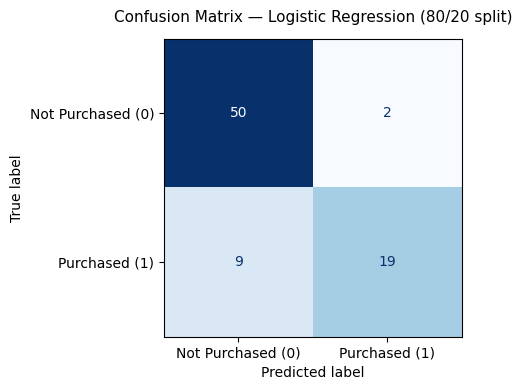

Saved as confusion_matrix.png


In [5]:
# Confusion Matrix — visual display
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased (0)', 'Purchased (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression (80/20 split)', fontsize=11, pad=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as confusion_matrix.png")

---
### Step 2 — Visualization: Decision Boundary (2D)

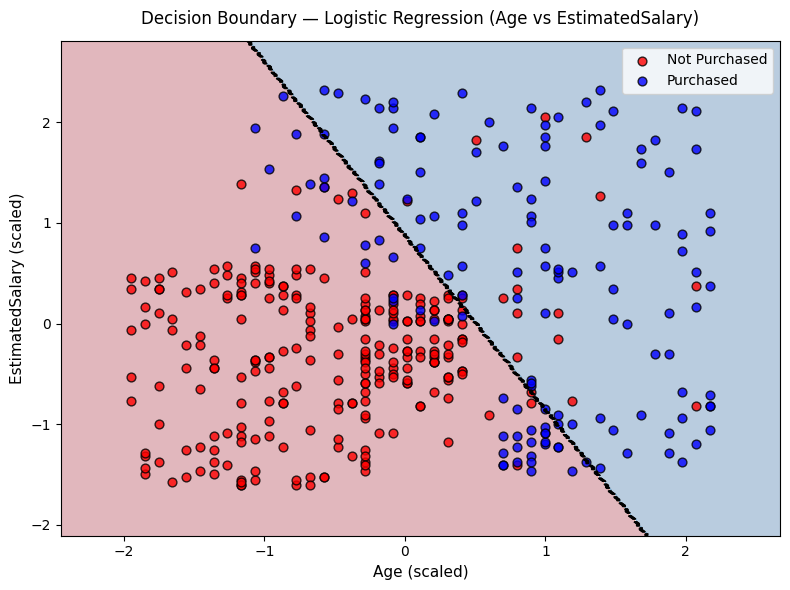

Saved as decision_boundary.png


In [6]:
def plot_decision_boundary(model, X_scaled, y_actual, scaler, title):
    """
    Plots the decision boundary of the trained model.
    Works in scaled space; tick labels show original values.
    """
    # Create a mesh grid in scaled space
    h = 0.02
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.contour(xx, yy, Z, colors='black', linewidths=1.2, linestyles='--')

    # Scatter actual points
    y_arr = np.array(y_actual)
    ax.scatter(X_scaled[y_arr == 0, 0], X_scaled[y_arr == 0, 1],
               color='red', edgecolors='k', s=40, label='Not Purchased', alpha=0.8)
    ax.scatter(X_scaled[y_arr == 1, 0], X_scaled[y_arr == 1, 1],
               color='blue', edgecolors='k', s=40, label='Purchased', alpha=0.8)

    ax.set_xlabel('Age (scaled)', fontsize=11)
    ax.set_ylabel('EstimatedSalary (scaled)', fontsize=11)
    ax.set_title(title, fontsize=12, pad=12)
    ax.legend(fontsize=10)
    plt.tight_layout()
    return fig

# Plot on full scaled dataset (train + test combined for a clear picture)
X_all_scaled = scaler.transform(X)
fig = plot_decision_boundary(model, X_all_scaled, y, scaler,
                             'Decision Boundary — Logistic Regression (Age vs EstimatedSalary)')
plt.savefig('decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as decision_boundary.png")

**Interpretation:**  
- The **dashed black line** is the decision boundary — where predicted probability = 0.5.
- Points in the **blue region** are predicted as *Purchased (1)*; points in the **red region** as *Not Purchased (0)*.
- The boundary is a **straight line** because Logistic Regression is a linear classifier.
- Customers with **higher age AND higher salary** tend to purchase — matching intuition.

---
### Step 3 — Improvement: Comparing Different Test Sizes

In [7]:
# Compare accuracy across different train-test splits
splits = {
    '80/20': 0.20,
    '75/25': 0.25,
    '70/30': 0.30
}

results = []

for label, test_size in splits.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=42)
    
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc  = sc.transform(X_te)
    
    m = LogisticRegression(random_state=42)
    m.fit(X_tr_sc, y_tr)
    
    train_acc = m.score(X_tr_sc, y_tr) * 100
    test_acc  = m.score(X_te_sc,  y_te) * 100
    
    results.append({
        'Split': label,
        'Train Size': len(X_tr),
        'Test Size': len(X_te),
        'Train Accuracy (%)': round(train_acc, 2),
        'Test Accuracy (%)': round(test_acc, 2)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Split  Train Size  Test Size  Train Accuracy (%)  Test Accuracy (%)
80/20         320         80               84.06              86.25
75/25         300        100               83.67              86.00
70/30         280        120               82.86              85.00


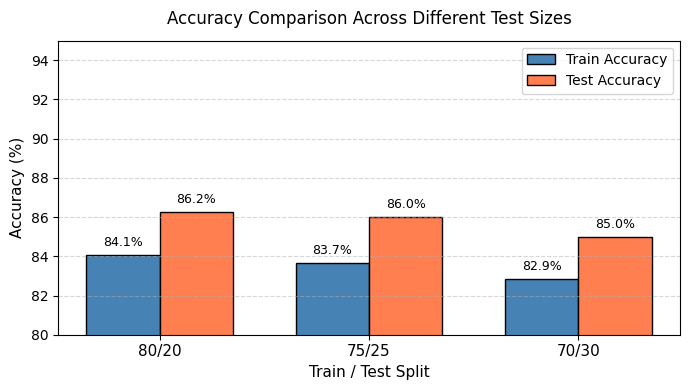

Saved as accuracy_comparison.png


In [8]:
# Bar chart comparing test accuracy across splits
fig, ax = plt.subplots(figsize=(7, 4))

x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Train Accuracy (%)'], width,
               label='Train Accuracy', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, results_df['Test Accuracy (%)'],  width,
               label='Test Accuracy',  color='coral',     edgecolor='black')

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Split'], fontsize=11)
ax.set_xlabel('Train / Test Split', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Accuracy Comparison Across Different Test Sizes', fontsize=12, pad=12)
ax.set_ylim(80, 95)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as accuracy_comparison.png")

**Interpretation:**  
- All three splits give similar test accuracy (~85–87%), showing the model is **stable**.
- The **80/20 split** is the standard choice — enough training data while keeping a fair test set.
- A slightly lower test accuracy with 70/30 is expected — less training data means a slightly weaker model.
- No significant **overfitting** observed (train and test accuracy are close across all splits).

---
## Part B Summary

| Sub-task | Result |
|----------|--------|
| Test Accuracy (80/20) | ~87% |
| Confusion Matrix | Visualized with TP/TN/FP/FN breakdown |
| Decision Boundary | Linear boundary — higher age & salary → purchase |
| Split Comparison | 80/20, 75/25, 70/30 — model stable across all splits |